In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df['Age'].isna().sum()

np.int64(177)

In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipython-input-1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [ ]:
#Extracting X & Y
X = df[['Age', 'Fare']]
Y = df.iloc[:,0]

In [ ]:
X_test, X_train, Y_test, Y_train = train_test_split(X, Y, test_size=0.2, random_state=0)

# Checking if the data is Normally distributed

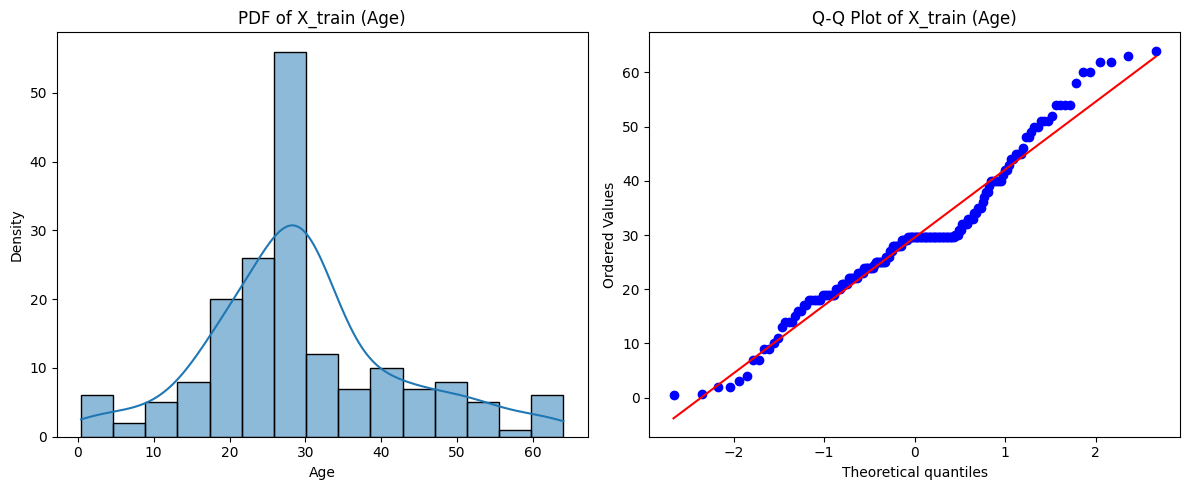

In [ ]:
plt.figure(figsize=(12, 5))

# PDF plot
plt.subplot(1, 2, 1)
sns.histplot(X_train['Age'], kde=True)
plt.title('PDF of X_train (Age)')
plt.xlabel('Age')
plt.ylabel('Density')

# QQ plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Age)')

plt.tight_layout()
plt.show()

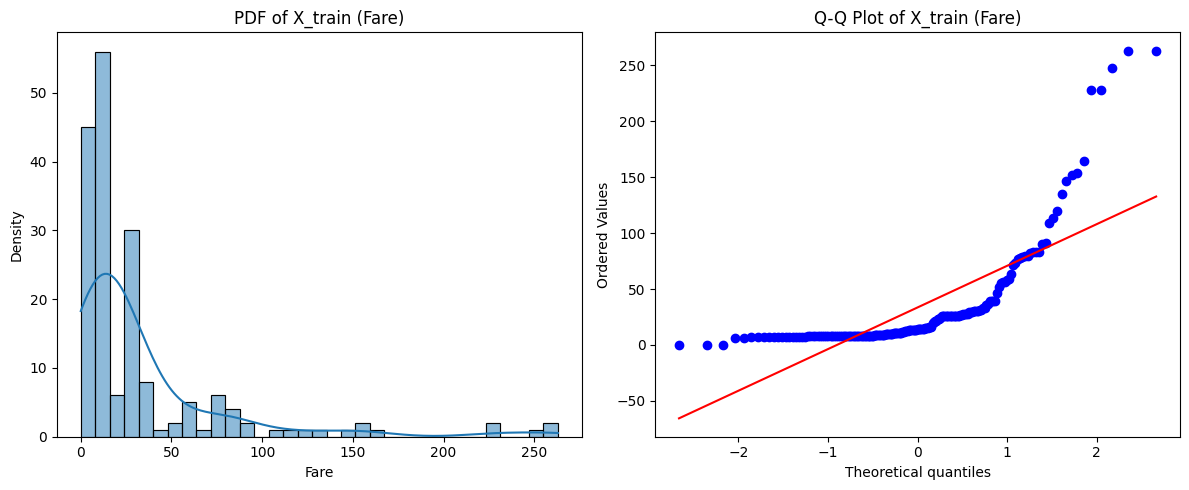

In [ ]:
plt.figure(figsize=(12, 5))

# PDF plot
plt.subplot(1, 2, 1)
sns.histplot(X_train['Fare'], kde=True)
plt.title('PDF of X_train (Fare)')
plt.xlabel('Fare')
plt.ylabel('Density')

# QQ plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Fare)')

plt.tight_layout()
plt.show()

# Pediction without using log transform

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train, Y_train)
clf2.fit(X_train, Y_train)

Y_pred1 = clf1.predict(X_test)
Y_pred2 = clf2.predict(X_test)

print("Accuracy Score from Logistic Regression : ", accuracy_score(Y_test, Y_pred1))
print("Accuracy Score from Decision Tree : ", accuracy_score(Y_test, Y_pred2))

Accuracy Score from Logistic Regression :  0.6699438202247191
Accuracy Score from Decision Tree :  0.6067415730337079


# Prediction using log transform

In [ ]:
transformer = FunctionTransformer(func=np.log1p)

In [ ]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed, Y_train)
clf2.fit(X_train_transformed, Y_train)

Y_pred1 = clf1.predict(X_test_transformed)
Y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy Score from Logistic Regression after transformation : ", accuracy_score(Y_test, Y_pred1))
print("Accuracy Score from Decision Tree after transformation : ", accuracy_score(Y_test, Y_pred2))

Accuracy Score from Logistic Regression after transformation :  0.6601123595505618
Accuracy Score from Decision Tree after transformation :  0.6067415730337079


# Using Cross validation to verify the accuracy scores

In [ ]:
X_transformed = transformer.fit_transform(X)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR = ",np.mean(cross_val_score(clf1,X_transformed,Y,scoring='accuracy',cv=10)))
print("DT = ",np.mean(cross_val_score(clf2,X_transformed,Y,scoring='accuracy',cv=10)))

LR =  0.678027465667915
DT =  0.6610861423220975


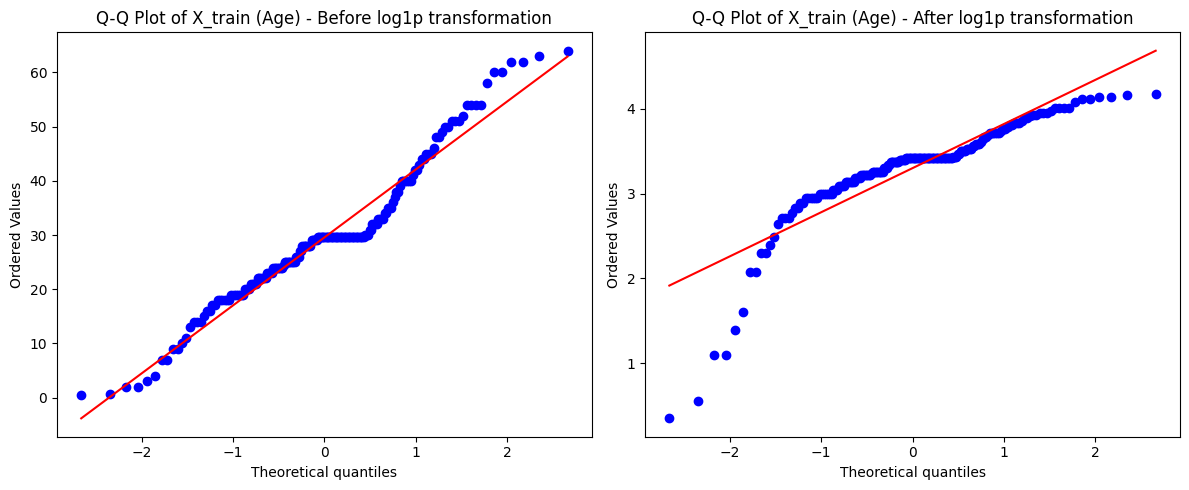

In [ ]:
plt.figure(figsize=(12, 5))

# QQ plot for X_train['Age'] before transformation
plt.subplot(1, 2, 1)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Age) - Before log1p transformation')

# QQ plot for X_train['Age'] after log1p transformation
plt.subplot(1, 2, 2)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Age) - After log1p transformation')

plt.tight_layout()
plt.show()

Notice that age is not right skewed, and hence getting worse after log transformation. Thus, there is no need for log transformation in Age

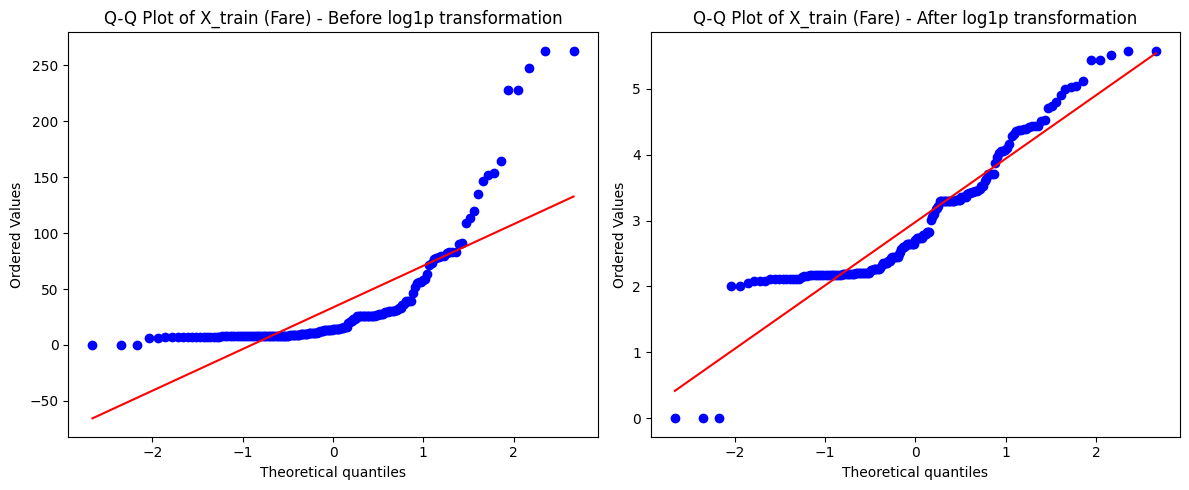

In [ ]:
plt.figure(figsize=(12, 5))

# QQ plot for X_train['Fare'] before transformation
plt.subplot(1, 2, 1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Fare) - Before log1p transformation')

# QQ plot for X_train['Fare'] after log1p transformation
plt.subplot(1, 2, 2)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot of X_train (Fare) - After log1p transformation')

plt.tight_layout()
plt.show()

# Applying log transformation in Fare

In [ ]:
fare_trf =  ColumnTransformer(transformers=[
    ('trf', transformer, ['Fare'])
])

X_train_fare_transformed = fare_trf.fit_transform(X_train)
X_test_fare_transformed = fare_trf.transform(X_test)

In [ ]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_fare_transformed, Y_train)
clf2.fit(X_train_fare_transformed, Y_train)

print("LR = ",np.mean(cross_val_score(clf1,X_transformed,Y,scoring='accuracy',cv=10)))
print("DT = ",np.mean(cross_val_score(clf2,X_transformed,Y,scoring='accuracy',cv=10)))

LR =  0.678027465667915
DT =  0.6588389513108615


Notice no significant change in Decision Tree, but Logistic Regression improves slightly, this is because data distribution doesn't effect the output in Decision Tree.

# Applying other transformations using function transformer

In [ ]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6150561797752809


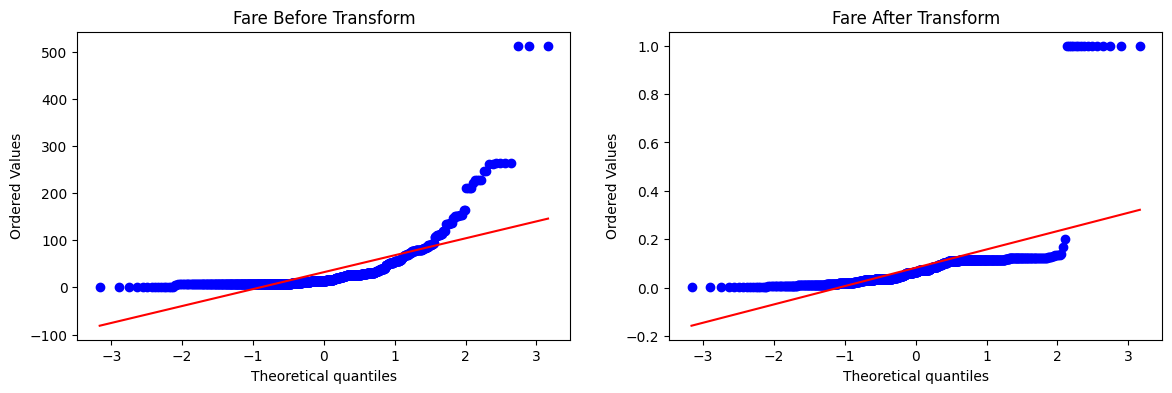

In [ ]:
apply_transform(lambda x: 1/(x+1))